# Notebook 05: ECM Pipeline & Scenario Analysis

We combine the Diebold-Li yield curve model and the ECM regime-switching repricing model
to answer the central ALM question:

> *Given a market rate scenario, what is the distribution of future deposit rates across segments?*

A key feature of the ECM is **sluggish adjustment**: deposit rates converge gradually
to the new equilibrium â€” unlike the static model, which assumes instant repricing.

| # | Scenario | Description | Assumed Regime |
|---|----------|-------------|----------------|
| 0 | Baseline | Factors stay at last observed value | Last filtered P(z=1) |
| 1 | Parallel +200 bp | Level +200bp | Regime 1 (hiking) |
| 2 | Parallel -100 bp | Level -100bp | Regime 0 (low rate) |
| 3 | Steepener | Slope +100bp | Keep current regime |
| 4 | Flattener | Slope -100bp | Keep current regime |

In [1]:
import sys
sys.path.insert(0, "../src")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from simulate import SEGMENTS, MATURITIES
from diebold_li import LAMBDA_MAT
from ecm_repricing import predict_deposit_rates_ecm

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
SEG_COLORS      = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3"]
SCENARIO_COLORS = ["#333333", "#d62728", "#1f77b4", "#8c564b", "#bcbd22"]

## 1. Load All Results

In [2]:
with open("../data/ecb_data.pkl", "rb") as f:
    ecb_data = pickle.load(f)
with open("../data/dl_results.pkl", "rb") as f:
    dl_results = pickle.load(f)
with open("../data/ecm_results.pkl", "rb") as f:
    ecm_results = pickle.load(f)

factors_hist  = dl_results["factors_filtered"]    # (T, 3) historical filtered factors
deposits_hist = ecb_data["deposits"]              # (T, S) historical deposit rates
xi_filtered   = ecm_results["xi_filtered"]         # (T-1, 2) filtered regime probs
idata_ecm     = ecm_results["idata"]
dates_hist    = factors_hist.index

# Arrays
factors_arr  = factors_hist.values.astype(np.float64)
deposits_arr = deposits_hist.values.astype(np.float64)

# Last observation: starting point for scenarios
f_last = factors_hist.iloc[-1].values    # [L, S, C]
p_hiking_last = float(xi_filtered["P_regime_1"].iloc[-1])

print(f"Last filtered factors  â€” L: {f_last[0]:.3f}%  S: {f_last[1]:.3f}%  C: {f_last[2]:.3f}%")
print(f"Last P(regime=hiking)  â€” {p_hiking_last:.3f}")

Last filtered factors  â€” L: 2.587%  S: 0.301%  C: -2.710%
Last P(regime=hiking)  â€” 1.000


## 2. Define Scenarios

Each scenario specifies:
1. A **12-month-ahead factor path** (linear interpolation to the shock endpoint).
2. An **assumed regime sequence** for the forecast horizon.

Regime assignment logic:
- **Parallel +200**: forced regime 1 (hiking)
- **Parallel -100**: forced regime 0 (low rate)
- **Baseline**: weighted average â€” regime $k$ drawn by Bernoulli(p_hiking_last) at each step
- **Steepener / Flattener**: keep last regime (rounded to {0,1})

In [3]:
H = 12   # forecast horizon (months)

# Scenario shocks at horizon H: delta applied to [Level, Slope, Curvature]
scenario_shocks = {
    "Baseline":       np.array([ 0.00,  0.00,  0.00]),
    "Parallel +200":  np.array([ 2.00,  0.00,  0.00]),
    "Parallel -100":  np.array([-1.00,  0.00,  0.00]),
    "Steepener +100": np.array([ 0.00,  1.00,  0.00]),
    "Flattener -100": np.array([ 0.00, -1.00,  0.00]),
}

def make_factor_path(f_start, shock, H):
    """Linear interpolation from f_start to f_start + shock over H periods."""
    t = np.linspace(0, 1, H + 1)[1:]   # (H,) â€” exclude t=0
    return f_start[None, :] + t[:, None] * shock[None, :]   # (H, 3)

scenario_paths = {
    name: make_factor_path(f_last, shock, H)
    for name, shock in scenario_shocks.items()
}

# Determine regime sequences
current_regime = int(p_hiking_last > 0.5)
rng_regime = np.random.default_rng(7)
scenario_regimes = {
    "Baseline":       rng_regime.binomial(1, p_hiking_last, H).astype(int),
    "Parallel +200":  np.ones(H, dtype=int),    # forced hiking
    "Parallel -100":  np.zeros(H, dtype=int),   # forced low rate
    "Steepener +100": np.full(H, current_regime, dtype=int),
    "Flattener -100": np.full(H, current_regime, dtype=int),
}

# Forecast dates
forecast_dates = pd.date_range(
    dates_hist[-1] + pd.DateOffset(months=1), periods=H, freq="MS"
)

print("Scenario endpoint factors (after 12 months) and assumed regime:")
print(f"{'Scenario':<22} {'Level':>7} {'Slope':>7} {'Curve':>7} {'Regime':>10}")
print("-" * 60)
for name, path in scenario_paths.items():
    l, s, c = path[-1]
    regime_label = {0: "Low rate", 1: "Hiking"}.get(scenario_regimes[name][-1], "Mixed")
    print(f"{name:<22} {l:>7.3f} {s:>7.3f} {c:>7.3f} {regime_label:>10}")

Scenario endpoint factors (after 12 months) and assumed regime:
Scenario                 Level   Slope   Curve     Regime
------------------------------------------------------------
Baseline                 2.587   0.301  -2.710     Hiking
Parallel +200            4.587   0.301  -2.710     Hiking
Parallel -100            1.587   0.301  -2.710   Low rate
Steepener +100           2.587   1.301  -2.710     Hiking
Flattener -100           2.587  -0.699  -2.710     Hiking


## 3. Implied Yield Curves at Horizon

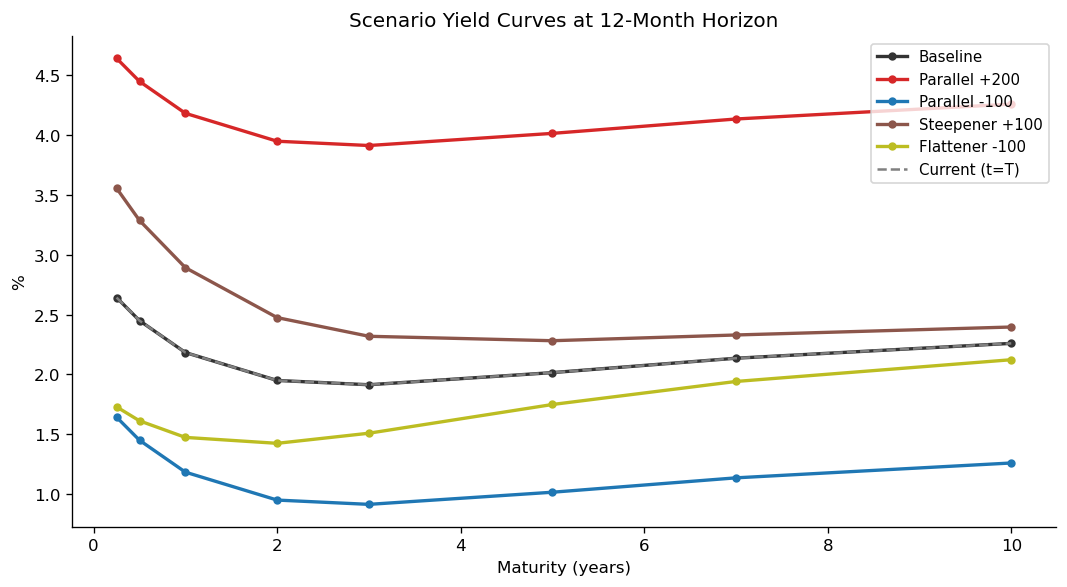

In [4]:
tau_yrs = MATURITIES / 12

fig, ax = plt.subplots(figsize=(9, 5))
for (name, path), c in zip(scenario_paths.items(), SCENARIO_COLORS):
    f_end = path[-1]           # (3,)
    yc    = LAMBDA_MAT @ f_end # (J,) yield curve at horizon
    ax.plot(tau_yrs, yc, color=c, lw=2.0, marker="o", ms=4, label=name)

# Current yield curve
yc_now = LAMBDA_MAT @ f_last
ax.plot(tau_yrs, yc_now, color="grey", lw=1.5, ls="--", label="Current (t=T)")

ax.set_title("Scenario Yield Curves at 12-Month Horizon")
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("%")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Deposit Rate Forecasts â€” ECM Posterior Predictive

For each scenario we draw from the full posterior predictive distribution of deposit rates.

Key difference from the static model: rates **converge gradually** to the new equilibrium
at a speed determined by the segment-specific $\gamma_s$.

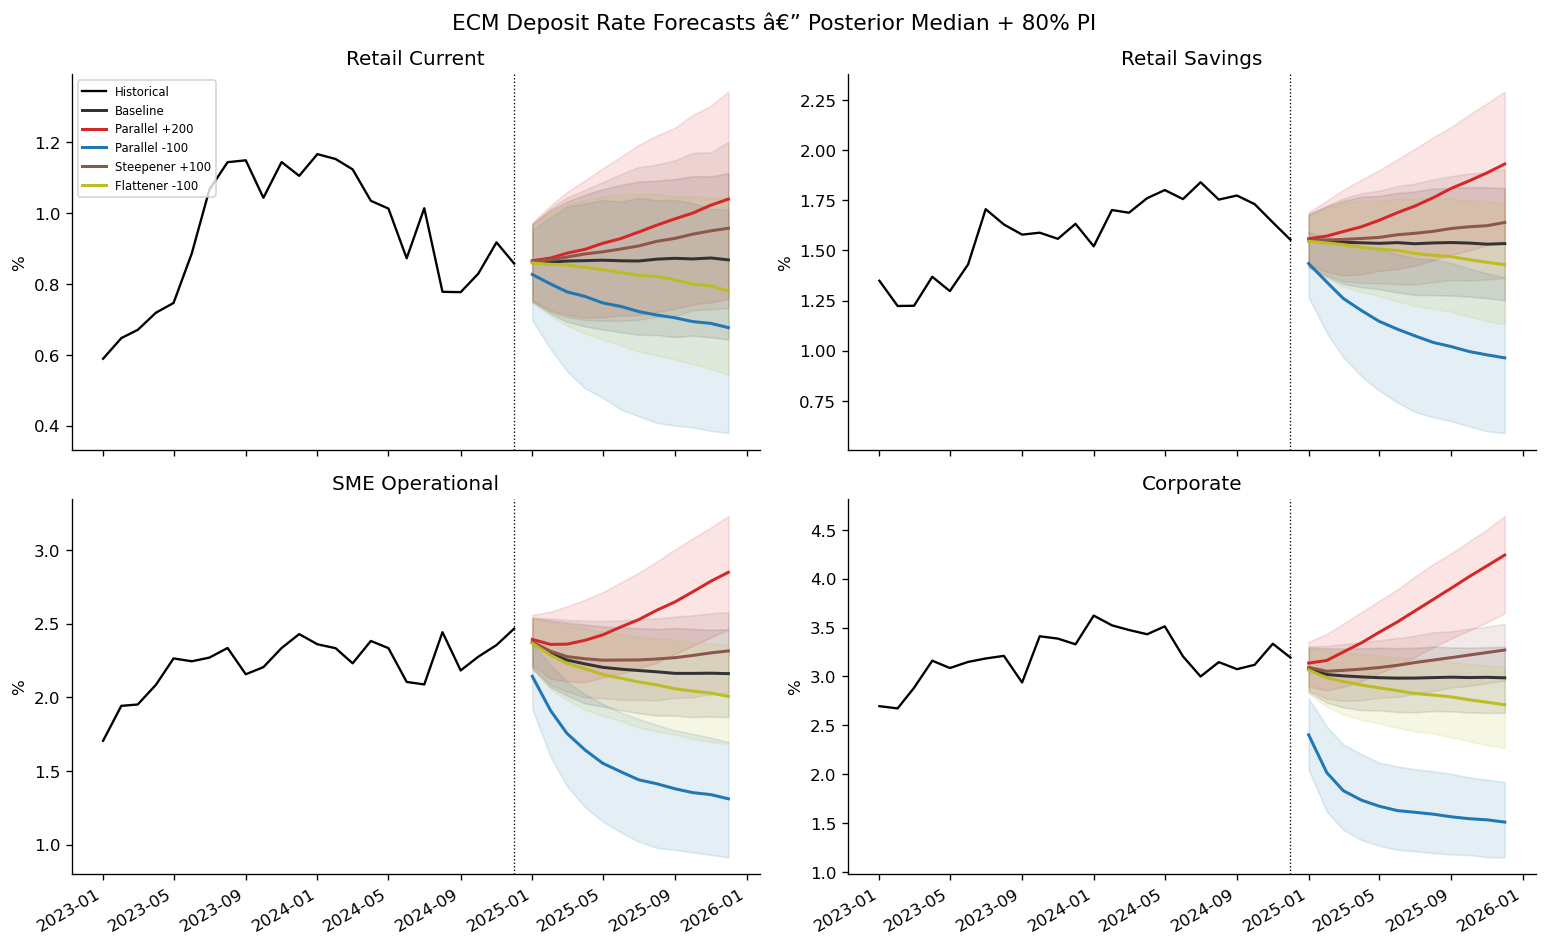

In [5]:
# Compute posterior predictive forecasts for all scenarios
forecast_ppc = {}
for name in scenario_paths:
    forecast_ppc[name] = predict_deposit_rates_ecm(
        idata_ecm,
        factors_arr,
        deposits_arr,
        scenario_paths[name],
        scenario_regimes[name],
    )  # (n_samples, H, S)

# Plot: one panel per segment, all scenarios overlaid
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for s, (ax, seg, seg_c) in enumerate(zip(axes.flat, SEGMENTS, SEG_COLORS)):
    # Historical (last 24 months)
    hist_dep = deposits_hist[seg].iloc[-24:]
    ax.plot(hist_dep.index, hist_dep.values, color="black", lw=1.4, label="Historical")

    for (name, ppc_arr), sc in zip(forecast_ppc.items(), SCENARIO_COLORS):
        lo  = np.percentile(ppc_arr[:, :, s], 10, axis=0)
        hi  = np.percentile(ppc_arr[:, :, s], 90, axis=0)
        med = np.median(ppc_arr[:, :, s], axis=0)
        ax.fill_between(forecast_dates, lo, hi, color=sc, alpha=0.12)
        ax.plot(forecast_dates, med, color=sc, lw=1.8, label=name)

    ax.axvline(dates_hist[-1], color="black", lw=0.8, ls=":")
    ax.set_title(seg)
    ax.set_ylabel("%")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    if s == 0:
        ax.legend(fontsize=7, loc="upper left")

fig.suptitle("ECM Deposit Rate Forecasts â€” Posterior Median + 80% PI", fontsize=13)
fig.autofmt_xdate(rotation=30)
fig.tight_layout()
plt.show()

## 5. ECM Path Convergence

Unlike the static model (which jumps immediately to the new equilibrium),
the ECM shows **gradual convergence**. We plot the path for each segment
under the Parallel +200bp scenario to illustrate the speed differential.

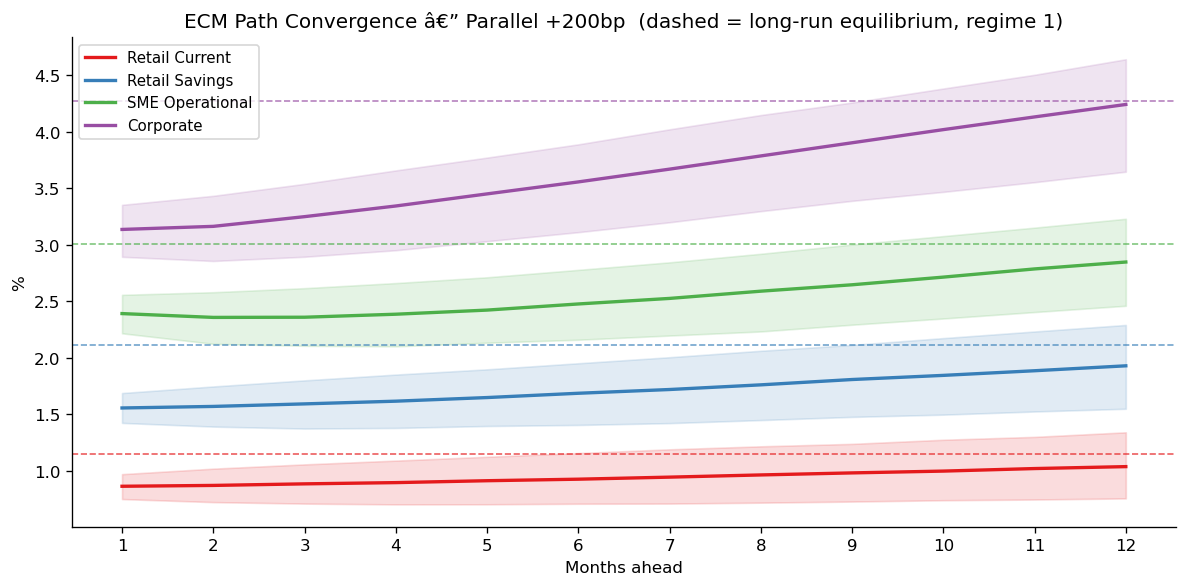

In [6]:
# Compute the long-run equilibrium under Parallel +200
post = idata_ecm.posterior
alpha_mean  = post["alpha"].mean(("chain", "draw")).values            # (S,)
beta_L_mean = post["beta_L"].mean(("chain", "draw")).values           # (2, S)
beta_S_mean = post["beta_S"].mean(("chain", "draw")).values           # (2, S)
beta_C_mean = post["beta_C"].mean(("chain", "draw")).values           # (S,)

# Long-run equilibrium at t+H (regime 1, end of +200 path)
f_end_200   = scenario_paths["Parallel +200"][-1]
r_eq_end    = (alpha_mean
               + beta_L_mean[1] * f_end_200[0]
               + beta_S_mean[1] * f_end_200[1]
               + beta_C_mean    * f_end_200[2])

# ECM path: median and 80% PI
ppc_200 = forecast_ppc["Parallel +200"]  # (N, H, S)

fig, ax = plt.subplots(figsize=(10, 5))
months = np.arange(1, H + 1)
for s, (seg, c) in enumerate(zip(SEGMENTS, SEG_COLORS)):
    med = np.median(ppc_200[:, :, s], axis=0)
    lo  = np.percentile(ppc_200[:, :, s], 10, axis=0)
    hi  = np.percentile(ppc_200[:, :, s], 90, axis=0)
    ax.fill_between(months, lo, hi, color=c, alpha=0.15)
    ax.plot(months, med, color=c, lw=2.0, label=seg)
    ax.axhline(r_eq_end[s], color=c, lw=1.0, ls="--", alpha=0.7)

ax.set_xlabel("Months ahead")
ax.set_ylabel("%")
ax.set_title("ECM Path Convergence â€” Parallel +200bp  (dashed = long-run equilibrium, regime 1)")
ax.legend(fontsize=9)
ax.set_xticks(months)
plt.tight_layout()
plt.show()

## 6. Pass-Through at Different Horizons

A key feature of the ECM is **horizon-dependent pass-through**:
at 1 month only a fraction of the long-run pass-through is realised;
by 12 months, most of the adjustment has occurred.

We compute the cumulative pass-through relative to the Baseline at horizons 1m, 3m, 6m, 12m.

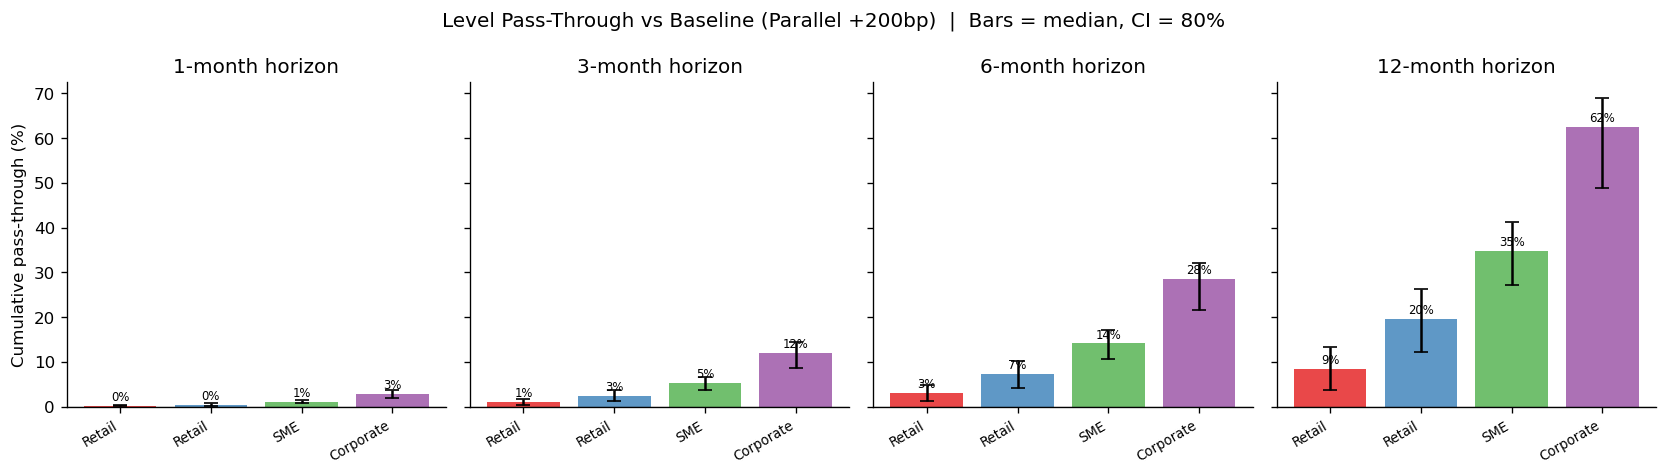

In [7]:
horizons = [1, 3, 6, 12]
shock_size = 2.0  # Parallel +200

ppc_base = forecast_ppc["Baseline"]     # (N, H, S)
ppc_up   = forecast_ppc["Parallel +200"]  # (N, H, S)

# Pass-through = (rate_up - rate_base) / shock_size  at each horizon
pass_through = {}  # horizon -> (N, S)
for h in horizons:
    pass_through[h] = (ppc_up[:, h - 1, :] - ppc_base[:, h - 1, :]) / shock_size

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
x = np.arange(len(SEGMENTS))
for ax, h in zip(axes, horizons):
    medians = np.median(pass_through[h], axis=0)
    lo      = np.percentile(pass_through[h], 10, axis=0)
    hi      = np.percentile(pass_through[h], 90, axis=0)
    bars = ax.bar(x, medians * 100, color=SEG_COLORS, alpha=0.8)
    for i, (m, l, u) in enumerate(zip(medians, lo, hi)):
        ax.errorbar(i, m * 100, yerr=[[( m - l) * 100], [(u - m) * 100]],
                    fmt="none", color="black", capsize=4, lw=1.5)
    ax.set_title(f"{h}-month horizon")
    ax.set_xticks(x)
    ax.set_xticklabels([s.split()[0] for s in SEGMENTS], rotation=30, ha="right", fontsize=8)
    ax.axhline(0, color="black", lw=0.7)
    if ax == axes[0]:
        ax.set_ylabel("Cumulative pass-through (%)")
    for bar, val in zip(bars, medians):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val*100:.0f}%", ha="center", va="bottom", fontsize=7)

fig.suptitle("Level Pass-Through vs Baseline (Parallel +200bp)  |  Bars = median, CI = 80%",
             fontsize=12)
fig.tight_layout()
plt.show()

## 7. Summary Table: Deposit Rates at 12-Month Horizon

Posterior median (80% PI) by scenario and segment.

In [8]:
rows = []
for name, ppc_arr in forecast_ppc.items():
    medians = np.median(ppc_arr[:, -1, :], axis=0)        # (S,) at H=12
    lo      = np.percentile(ppc_arr[:, -1, :], 10, axis=0)
    hi      = np.percentile(ppc_arr[:, -1, :], 90, axis=0)
    row = {"Scenario": name}
    for s, seg in enumerate(SEGMENTS):
        row[seg] = f"{medians[s]:.2f} [{lo[s]:.2f}, {hi[s]:.2f}]"
    rows.append(row)

summary = pd.DataFrame(rows).set_index("Scenario")
print("Posterior median (80% PI) deposit rate at 12-month horizon (%)")
print("=" * 100)
print(summary.to_string())

Posterior median (80% PI) deposit rate at 12-month horizon (%)
                   Retail Current     Retail Savings    SME Operational          Corporate
Scenario                                                                                  
Baseline        0.87 [0.64, 1.11]  1.53 [1.25, 1.81]  2.16 [1.86, 2.46]  2.99 [2.63, 3.30]
Parallel +200   1.04 [0.76, 1.34]  1.93 [1.55, 2.29]  2.85 [2.46, 3.23]  4.24 [3.65, 4.64]
Parallel -100   0.68 [0.38, 1.01]  0.96 [0.59, 1.37]  1.31 [0.91, 1.70]  1.51 [1.15, 1.92]
Steepener +100  0.96 [0.73, 1.20]  1.64 [1.36, 1.91]  2.31 [2.03, 2.58]  3.27 [2.96, 3.54]
Flattener -100  0.78 [0.54, 1.04]  1.43 [1.13, 1.73]  2.01 [1.68, 2.35]  2.71 [2.27, 3.10]


## 8. Save Results

Persist all scenario data for notebook 06 (volume model).

In [9]:
import os
os.makedirs("../data", exist_ok=True)

pipeline_results = {
    "scenario_names":    list(scenario_paths.keys()),
    "scenario_factors":  scenario_paths,
    "scenario_regimes":  scenario_regimes,
    "scenario_deposits": forecast_ppc,
    "forecast_dates":    forecast_dates,
    "factors_hist":      factors_hist,
    "deposits_hist":     deposits_hist,
    "xi_filtered":       xi_filtered,
    "H":                 H,
}

with open("../data/pipeline_results.pkl", "wb") as f:
    pickle.dump(pipeline_results, f)

print("Saved pipeline_results.pkl")


Saved pipeline_results.pkl
